<a href="https://colab.research.google.com/github/guravharshvardhan/Deep-Learning/blob/main/Experiment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
# Use smaller dataset for faster training
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

In [ ]:
# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Convert labels into categorical (one-hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

NameError: name 'to_categorical' is not defined

In [ ]:
# Resize images to 96x96 for MobileNetV2
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

In [ ]:
# Load MobileNetV2 without top layer
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(96,96,3))

In [ ]:
# Freeze all layers (no training)
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Add custom layers on top
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=output)

In [ ]:
# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train only top layers
history1 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 263ms/step - accuracy: 0.6915 - loss: 0.8943 - val_accuracy: 0.7660 - val_loss: 0.7023
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 251ms/step - accuracy: 0.7898 - loss: 0.5990 - val_accuracy: 0.7535 - val_loss: 0.7241
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 266ms/step - accuracy: 0.8229 - loss: 0.4964 - val_accuracy: 0.7615 - val_loss: 0.7194


In [ ]:
# Unfreeze last 10 layers for fine-tuning
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [ ]:
# Compile again with lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train again (fine-tuning)
history2 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 325ms/step - accuracy: 0.7405 - loss: 0.7678 - val_accuracy: 0.7815 - val_loss: 0.6924
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 346ms/step - accuracy: 0.8013 - loss: 0.5816 - val_accuracy: 0.7835 - val_loss: 0.6903
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.8216 - loss: 0.5187 - val_accuracy: 0.7845 - val_loss: 0.6792


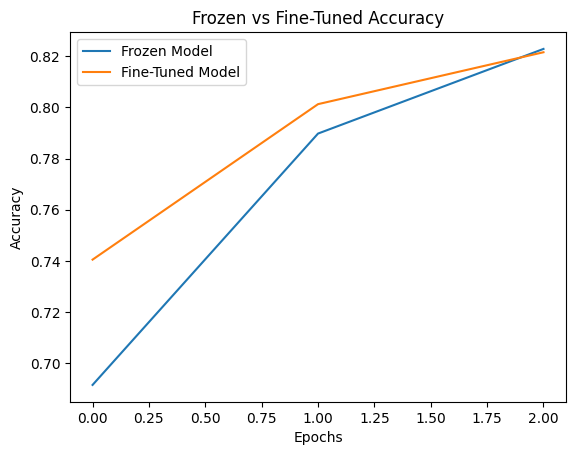

In [ ]:
# Plot accuracy of both phases
plt.plot(history1.history['accuracy'], label='Frozen Model')
plt.plot(history2.history['accuracy'], label='Fine-Tuned Model')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Frozen vs Fine-Tuned Accuracy')
plt.legend()
plt.show()

In [ ]:
# Predict on test data
pred = model.predict(x_test)

# Show predicted class of first image
print("Predicted class:", pred[0].argmax())

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 250ms/step
Predicted class: 3
